<a href="https://colab.research.google.com/github/davidzapata439/Python-Prep/blob/main/Base_Proyecto_Redes_Neuronales_recurrentes_de_predicion_2.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
# Librerías necesarias
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense, Dropout, GRU
from tensorflow.keras.regularizers import l2
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau
from tensorflow.keras.optimizers import Adam

# Carga manual del archivo CSV
from google.colab import files

In [ ]:
uploaded = files.upload()  # Selecciona archivo CSV con columnas: timestamp, demand

# Leer el archivo
df = pd.read_csv(next(iter(uploaded)))
df['Datetime'] = pd.to_datetime(df['Datetime'])
df = df.sort_values('Datetime')
df.set_index('Datetime', inplace=True)

# Normalización [0, 1]
scaler = MinMaxScaler()
data_scaled = scaler.fit_transform(df[['PJMW_MW']])

Saving PJMW_hourly.csv to PJMW_hourly.csv


In [ ]:
# 🪟 Crear secuencias de 24 horas
def create_sequences(data, window_size):
    X, y = [], []
    for i in range(len(data) - window_size):
        X.append(data[i:i+window_size])
        y.append(data[i+window_size])
    return np.array(X), np.array(y)

window_size = 24
X, y = create_sequences(data_scaled, window_size)


In [ ]:

# Modelo LSTM
model = Sequential()
model.add(GRU(256, input_shape=(window_size, 1), return_sequences=False,
               kernel_regularizer=l2(0.0001)))  # Regularización L2
model.add(Dropout(0.2))  # Dropout para evitar overfitting
model.add(Dense(1))  # Capa de salida para predicción

model.summary()

/usr/local/lib/python3.12/dist-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Model: "sequential_18"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ gru_5 (GRU)                     │ (None, 256)            │       198,912 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_15 (Dropout)            │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_15 (Dense)                │ (None, 1)              │           257 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 199,169 (778.00 KB)

 Trainable params: 199,169 (778.00 KB)

 Non-trainable params: 0 (0.00 B)

In [ ]:
# División en entrenamiento, validación y prueba (70/15/15)
train_size = int(0.7 * len(X))
val_size   = int(0.15 * len(X))

X_train, y_train = X[:train_size],                    y[:train_size]
X_val,   y_val   = X[train_size:train_size+val_size], y[train_size:train_size+val_size]
X_test,  y_test  = X[train_size+val_size:],           y[train_size+val_size:]


# Compilación del modelo
model.compile(loss='mse', optimizer=Adam(learning_rate=0.001))

# ── Callbacks ────────────────────────────────────────────────────────────────

# Early Stopping:
# Detiene el entrenamiento si 'val_loss' no mejora en 'patience' épocas.
# restore_best_weights=True → recupera los pesos de la mejor época al terminar.
early_stop = EarlyStopping(
    monitor='val_loss',
    patience=3,
    restore_best_weights=True,
    verbose=1
)

# Reduce Learning Rate on Plateau:
# Cuando 'val_loss' deja de bajar por 'patience' épocas, multiplica el
# learning rate por 'factor' (ej. 0.0001 → 0.00005).
# Esto permite afinar el modelo con pasos más pequeños cuando se estanca.
#   monitor  → métrica a observar
#   factor   → nuevo_lr = lr * factor  (0.5 = reducir a la mitad)
#   patience → épocas a esperar antes de reducir
#   min_lr   → límite inferior del learning rate (no baja de este valor)
reduce_lr = ReduceLROnPlateau(
    monitor='val_loss',
    factor=0.5,
    patience=2,
    min_lr=1e-7,
    verbose=1
)

# Entrenamiento
history = model.fit(
    X_train, y_train,
    validation_data=(X_val, y_val),
    epochs=20,
    batch_size=128,
    callbacks=[early_stop, reduce_lr],   # ← ambos callbacks activos
    verbose=1
)

# Evaluación en conjunto de prueba
y_pred = model.predict(X_test)

# Inversa de la normalización
y_test_inv = scaler.inverse_transform(y_test)
y_pred_inv = scaler.inverse_transform(y_pred)

# Métricas
mse = mean_squared_error(y_test_inv, y_pred_inv)
mae = mean_absolute_error(y_test_inv, y_pred_inv)
r2 = r2_score(y_test_inv, y_pred_inv)


Epoch 1/20
784/784 ━━━━━━━━━━━━━━━━━━━━ 7s 8ms/step - loss: 0.0114 - val_loss: 7.1836e-04 - learning_rate: 0.0010
Epoch 2/20
784/784 ━━━━━━━━━━━━━━━━━━━━ 5s 6ms/step - loss: 9.7209e-04 - val_loss: 4.2085e-04 - learning_rate: 0.0010
Epoch 3/20
784/784 ━━━━━━━━━━━━━━━━━━━━ 6s 7ms/step - loss: 7.5399e-04 - val_loss: 3.3715e-04 - learning_rate: 0.0010
Epoch 4/20
784/784 ━━━━━━━━━━━━━━━━━━━━ 5s 6ms/step - loss: 6.3140e-04 - val_loss: 3.1246e-04 - learning_rate: 0.0010
Epoch 5/20
784/784 ━━━━━━━━━━━━━━━━━━━━ 5s 6ms/step - loss: 5.6867e-04 - val_loss: 2.8726e-04 - learning_rate: 0.0010
Epoch 6/20
784/784 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - loss: 5.0529e-04
Epoch 6: ReduceLROnPlateau reducing learning rate to 0.0005000000237487257.
784/784 ━━━━━━━━━━━━━━━━━━━━ 6s 8ms/step - loss: 5.0528e-04 - val_loss: 2.5118e-04 - learning_rate: 0.0010
Epoch 7/20
784/784 ━━━━━━━━━━━━━━━━━━━━ 5s 6ms/step - loss: 4.4257e-04 - val_loss: 2.4801e-04 - learning_rate: 5.0000e-04
Epoch 8/20
777/784 ━━━━━━━━━━━━━━━━━━━

In [ ]:
# Evaluación en conjunto de prueba
y_pred = model.predict(X_test)

# Inversa de la normalización
y_test_inv = scaler.inverse_transform(y_test)
y_pred_inv = scaler.inverse_transform(y_pred)

# Métricas
mse = mean_squared_error(y_test_inv, y_pred_inv)
mae = mean_absolute_error(y_test_inv, y_pred_inv)
r2  = r2_score(y_test_inv, y_pred_inv)

# ── Mostrar resultados ───────────────────────────────────────────────────────
print("=" * 45)
print("       EVALUACIÓN DEL MODELO — TEST SET")
print("=" * 45)
print(f"  MSE  (Error Cuadrático Medio):  {mse:.4f}")
print(f"  RMSE (Raíz del MSE):            {mse**0.5:.4f}")
print(f"  MAE  (Error Absoluto Medio):    {mae:.4f}")
print(f"  R²   (Coef. de determinación):  {r2:.4f}")
print("=" * 45)

# Interpretación automática del R²
if r2 >= 0.90:
    print("  Resultado: EXCELENTE  (R² ≥ 0.90)")
elif r2 >= 0.75:
    print("  Resultado: BUENO      (R² ≥ 0.75)")
elif r2 >= 0.50:
    print("  Resultado: MODERADO   (R² ≥ 0.50)")
else:
    print("  Resultado: BAJO       (R² < 0.50) — revisar modelo")
print("=" * 45)


672/672 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step
       EVALUACIÓN DEL MODELO — TEST SET
  MSE  (Error Cuadrático Medio):  10962.8711
  RMSE (Raíz del MSE):            104.7037
  MAE  (Error Absoluto Medio):    80.8016
  R²   (Coef. de determinación):  0.9887
  Resultado: EXCELENTE  (R² ≥ 0.90)


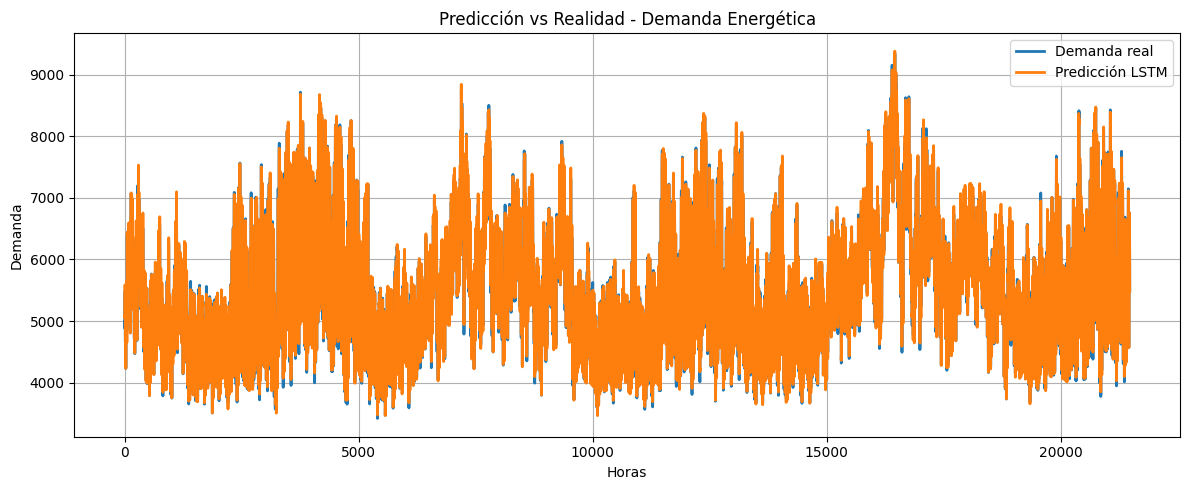

In [ ]:
# Gráfico de predicción vs realidad
plt.figure(figsize=(12, 5))
plt.plot(y_test_inv, label='Demanda real', linewidth=2)
plt.plot(y_pred_inv, label='Predicción LSTM', linewidth=2)
plt.title('Predicción vs Realidad - Demanda Energética')
plt.xlabel('Horas')
plt.ylabel('Demanda')
plt.legend()
plt.tight_layout()
plt.grid(True)
plt.show()


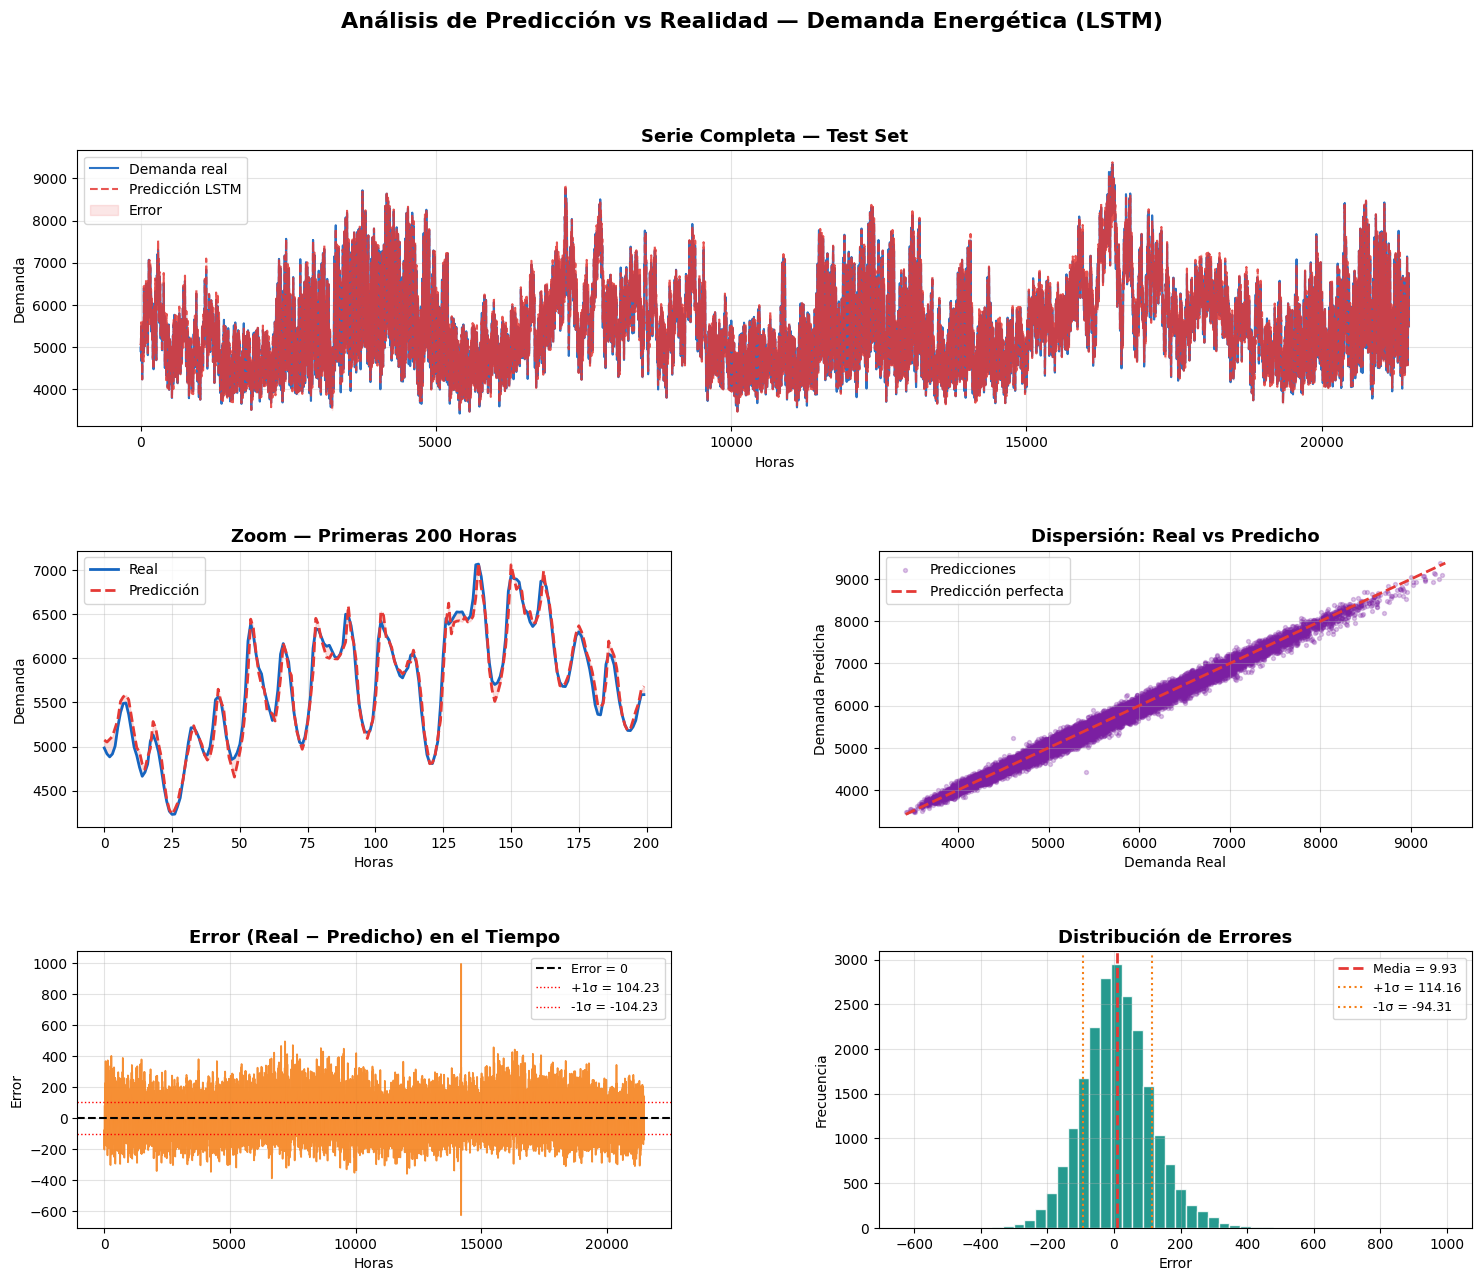

In [ ]:
# ── Preparar datos ────────────────────────────────────────────────────────────
y_real = y_test_inv.flatten()
y_pred = y_pred_inv.flatten()
errores = y_real - y_pred
horas   = np.arange(len(y_real))

# Muestra reducida para el zoom (primeras 200 horas)
zoom_n = 200

fig = plt.figure(figsize=(18, 14))
fig.suptitle('Análisis de Predicción vs Realidad — Demanda Energética (LSTM)',
             fontsize=16, fontweight='bold', y=0.98)

gs = gridspec.GridSpec(3, 2, figure=fig, hspace=0.45, wspace=0.35)

# ── Gráfico 1: Serie completa ─────────────────────────────────────────────────
ax1 = fig.add_subplot(gs[0, :])   # ocupa toda la fila superior
ax1.plot(horas, y_real, label='Demanda real',       color='#1565C0', linewidth=1.5, alpha=0.9)
ax1.plot(horas, y_pred, label='Predicción LSTM',    color='#E53935', linewidth=1.5, alpha=0.85, linestyle='--')
ax1.fill_between(horas, y_real, y_pred, alpha=0.12, color='#E53935', label='Error')
ax1.set_title('Serie Completa — Test Set',           fontsize=13, fontweight='bold')
ax1.set_xlabel('Horas')
ax1.set_ylabel('Demanda')
ax1.legend(fontsize=10)
ax1.grid(True, alpha=0.35)

# ── Gráfico 2: Zoom primeras 200 horas ───────────────────────────────────────
ax2 = fig.add_subplot(gs[1, 0])
ax2.plot(horas[:zoom_n], y_real[:zoom_n], label='Real',       color='#1565C0', linewidth=2)
ax2.plot(horas[:zoom_n], y_pred[:zoom_n], label='Predicción', color='#E53935', linewidth=2, linestyle='--')
ax2.fill_between(horas[:zoom_n], y_real[:zoom_n], y_pred[:zoom_n], alpha=0.15, color='#E53935')
ax2.set_title(f'Zoom — Primeras {zoom_n} Horas',              fontsize=13, fontweight='bold')
ax2.set_xlabel('Horas')
ax2.set_ylabel('Demanda')
ax2.legend(fontsize=10)
ax2.grid(True, alpha=0.35)

# ── Gráfico 3: Dispersión Real vs Predicho ────────────────────────────────────
ax3 = fig.add_subplot(gs[1, 1])
ax3.scatter(y_real, y_pred, alpha=0.25, s=8, color='#7B1FA2', label='Predicciones')
# Línea perfecta (si pred == real, todos los puntos caerían aquí)
min_v, max_v = min(y_real.min(), y_pred.min()), max(y_real.max(), y_pred.max())
ax3.plot([min_v, max_v], [min_v, max_v], color='#E53935', linewidth=2,
         linestyle='--', label='Predicción perfecta')
ax3.set_title('Dispersión: Real vs Predicho',                  fontsize=13, fontweight='bold')
ax3.set_xlabel('Demanda Real')
ax3.set_ylabel('Demanda Predicha')
ax3.legend(fontsize=10)
ax3.grid(True, alpha=0.35)

# ── Gráfico 4: Error a lo largo del tiempo ────────────────────────────────────
ax4 = fig.add_subplot(gs[2, 0])
ax4.plot(horas, errores, color='#F57F17', linewidth=1.2, alpha=0.85)
ax4.axhline(0,            color='black',  linewidth=1.5, linestyle='--', label='Error = 0')
ax4.axhline( errores.std(), color='red',   linewidth=1,  linestyle=':',  label=f'+1σ = {errores.std():.2f}')
ax4.axhline(-errores.std(), color='red',   linewidth=1,  linestyle=':',  label=f'-1σ = {-errores.std():.2f}')
ax4.fill_between(horas, errores, 0, alpha=0.15, color='#F57F17')
ax4.set_title('Error (Real − Predicho) en el Tiempo',          fontsize=13, fontweight='bold')
ax4.set_xlabel('Horas')
ax4.set_ylabel('Error')
ax4.legend(fontsize=9)
ax4.grid(True, alpha=0.35)

# ── Gráfico 5: Histograma de errores ─────────────────────────────────────────
ax5 = fig.add_subplot(gs[2, 1])
ax5.hist(errores, bins=50, color='#00897B', edgecolor='white', alpha=0.85)
ax5.axvline(errores.mean(), color='#E53935', linewidth=2,
            linestyle='--', label=f'Media = {errores.mean():.2f}')
ax5.axvline(errores.mean() + errores.std(), color='#F57F17', linewidth=1.5,
            linestyle=':',  label=f'+1σ = {errores.mean()+errores.std():.2f}')
ax5.axvline(errores.mean() - errores.std(), color='#F57F17', linewidth=1.5,
            linestyle=':',  label=f'-1σ = {errores.mean()-errores.std():.2f}')
ax5.set_title('Distribución de Errores',                        fontsize=13, fontweight='bold')
ax5.set_xlabel('Error')
ax5.set_ylabel('Frecuencia')
ax5.legend(fontsize=9)
ax5.grid(True, alpha=0.35)

plt.savefig('evaluacion_lstm.png', dpi=150, bbox_inches='tight')
plt.show()